# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [101]:
from typing import Required
# Import necessary libraries
import os
import re
import nltk
import json
import zipfile
import numpy as np
import pandas as pd
import random
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# Required nltk resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [103]:
zip_path = 'realwaste.zip'
extract_path = '/content'
if os.path.exists(zip_path):
    print("Found zip file in Google Drive. Starting extraction...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extraction complete! Images are saved locally at: {extract_path}")
else:
    print(f"Error: Could not find the file at {zip_path}. Check your Drive folder structure.")


Found zip file in Google Drive. Starting extraction...
Extraction complete! Images are saved locally at: /content


Waste Categories:
['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']

Number of Categories: 9


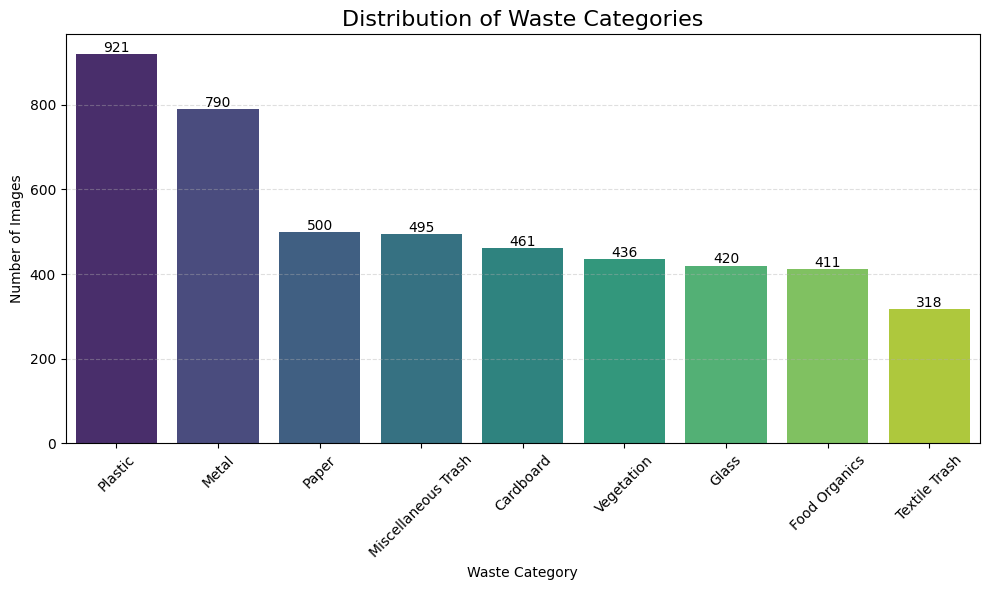

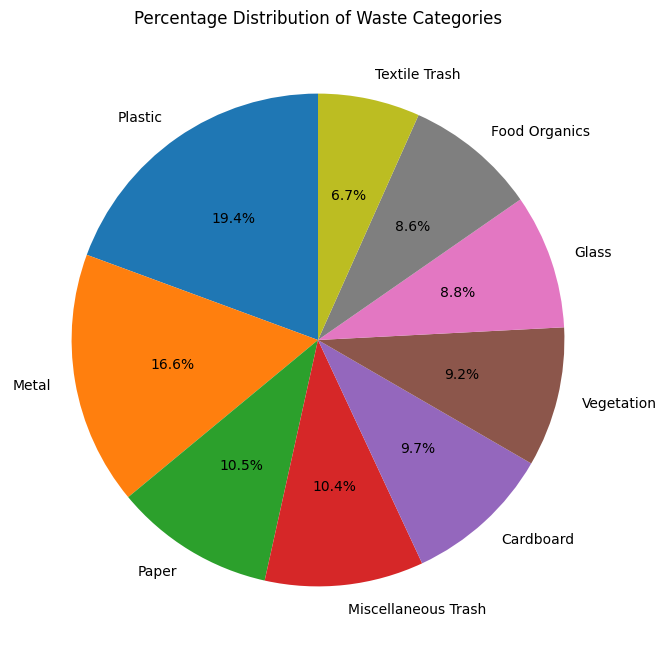

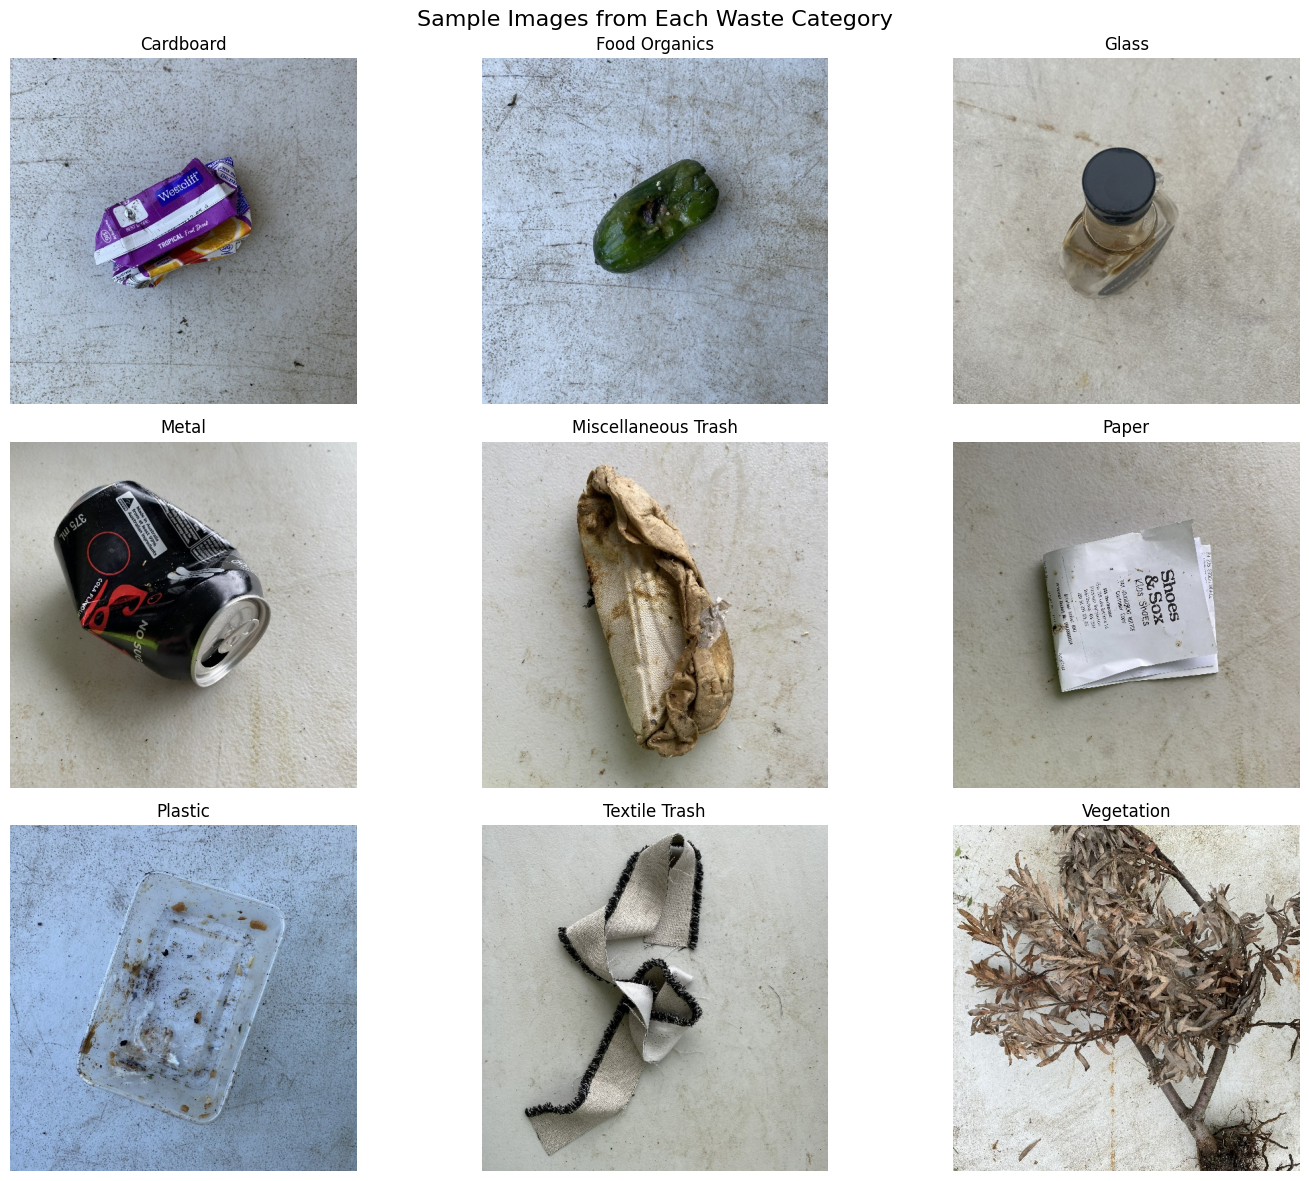

Number of unique image sizes: 1

Most common image sizes:
(524, 524): 4752 images
Resolution Distribution:
        Width  Height
count  4752.0  4752.0
mean    524.0   524.0
std       0.0     0.0
min     524.0   524.0
25%     524.0   524.0
50%     524.0   524.0
75%     524.0   524.0
max     524.0   524.0
Counter({'RGB': 4752})


In [104]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
dataset_path = "/content/realwaste-main/RealWaste"

# List all category folders
categories = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Waste Categories:")
print(categories)

print(f"\nNumber of Categories: {len(categories)}")

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

# images count per category
image_counts = []

for category in categories:
    folder_path = os.path.join(dataset_path, category)

    count = len([
        file for file in os.listdir(folder_path)
        if file.lower().endswith(VALID_EXTENSIONS)
    ])

    image_counts.append({
        "Category": category,
        "Images": count
    })

distribution_df = pd.DataFrame(image_counts).sort_values("Images", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=distribution_df,
    x="Category",
    y="Images",
    hue="Category",
    legend=False,
    palette="viridis"
)

plt.title("Distribution of Waste Categories", fontsize=16)
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Display image counts on top of each bar
for index, value in enumerate(distribution_df["Images"]):
    plt.text(index, value + 5, str(value),
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

distribution_df["Percentage"] = (
    distribution_df["Images"] /
    distribution_df["Images"].sum() * 100
).round(2)

distribution_df

plt.figure(figsize=(8, 8))

plt.pie(
    distribution_df["Images"],
    labels=distribution_df["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Waste Categories")
plt.show()

# Display sample images
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    folder = os.path.join(dataset_path, category)

    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis("off")

plt.suptitle("Sample Images from Each Waste Category", fontsize=16)
plt.tight_layout()
plt.show()

# analyze image resolution
image_sizes = []

for category in categories:
    folder = os.path.join(dataset_path, category)
    if not os.path.exists(folder):
        continue
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        if os.path.isdir(img_path):
            continue
        if img_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size) # (width, height)
            except Exception as e:
                # Print the error if an image fails to open so you know why
                print(f"Error opening {img_name}: {e}")
                continue


size_counts = Counter(image_sizes)

print(f"Number of unique image sizes: {len(size_counts)}")
print("\nMost common image sizes:")

for size, count in size_counts.most_common(10):
    print(f"{size}: {count} images")

# resolution distribution
resolution_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])

print(f"Resolution Distribution:\n{resolution_df.describe()}")

# Determine whether all images are RGB
color_modes = Counter()

for category in categories:
    folder = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            with Image.open(img_path) as img:
                color_modes[img.mode] += 1
        except Exception:
            continue

print(color_modes)

### 1.2 Explore Text Datasets

Shape: (5000, 5)

Columns:
['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition'] 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB

Missing values:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64
Basic statistics
         description    category               disposal_instruction  \
count          5000        5000                               5000   
unique         4939           9            

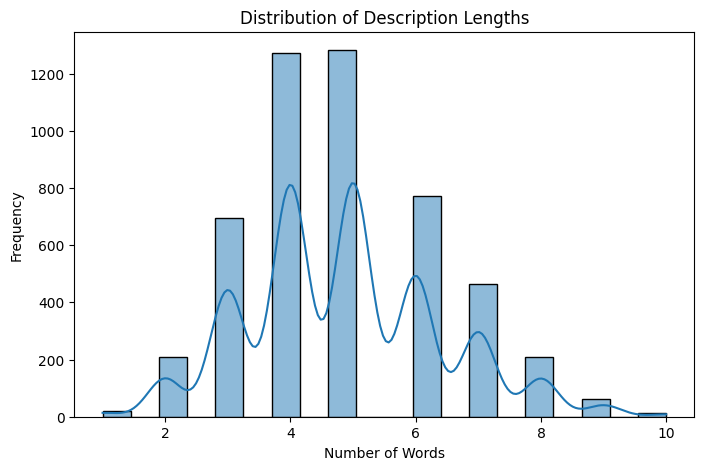

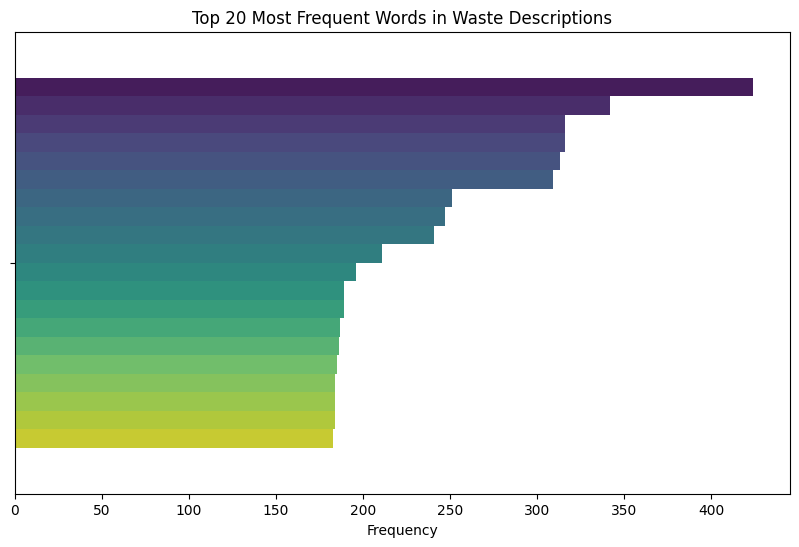

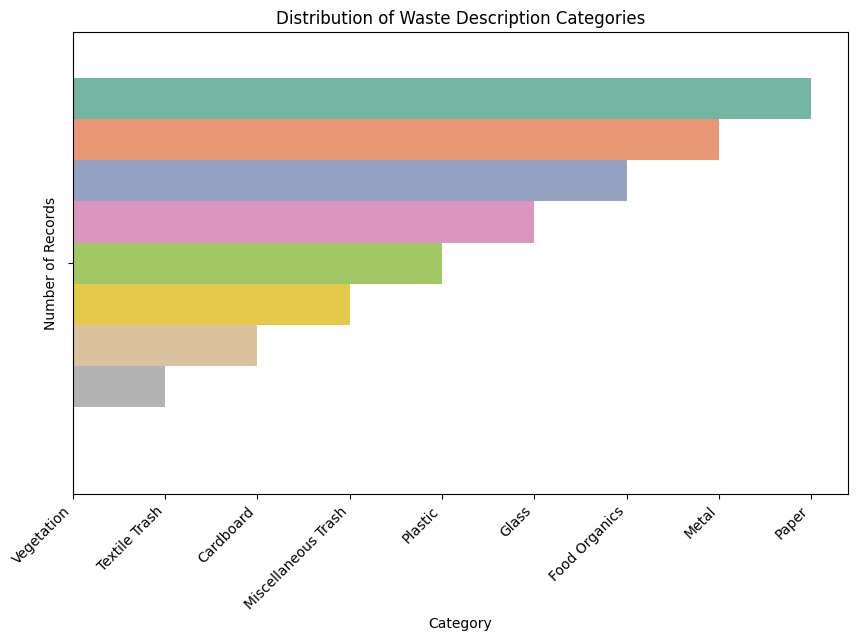

In [105]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
descriptions_df = pd.read_csv("waste_descriptions.csv")

# Display the first few rows
descriptions_df.head()

# Inspect dataset
# Dataset dimensions
print(f"Shape: {descriptions_df.shape}")

# Column names
print("\nColumns:")
print(descriptions_df.columns.tolist(), "\n\n")

# Data types and missing values
descriptions_df.info()

# check missing values
print(f"\nMissing values:\n{descriptions_df.isnull().sum()}")

# basic statistics
print("Basic statistics\n", descriptions_df.describe(include="all"))

# ==========================================
# Vocabulary Structure
# ==========================================
# Calculate the number of words in each description
descriptions_df["word_count"] = (
    descriptions_df["description"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(f"\nWord count stats{descriptions_df["word_count"].describe()}")

# visualize description length
plt.figure(figsize=(8,5))

sns.histplot(
    descriptions_df["word_count"],
    bins=20,
    kde=True
)

plt.title("Distribution of Description Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()
print()
# Most frequent words
all_words = " ".join(
    descriptions_df["description"].astype(str)
).lower().split()

filtered_words = [
    word.strip(".,!?()[]{}")
    for word in all_words
    if word not in ENGLISH_STOP_WORDS
]

word_counts = Counter(filtered_words)

word_counts.most_common(20)

# convert to dataframe for easier visualization
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

# Visualize most common words
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    x="Frequency",
    hue="Word",
    palette="viridis",
    legend=False
)

plt.title("Top 20 Most Frequent Words in Waste Descriptions")

plt.show()

# ==========================================
# Understand the distribution of categories
# ==========================================
category_counts = (
    descriptions_df["category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Count"]

category_counts
print()
# visualize distribution
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_counts,
    x="Category",
    hue="Count",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Waste Description Categories")
plt.xlabel("Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")

plt.show()

<class 'list'>
Number of documents: 14

Shape (14, 6) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes
None

   policy_id                         policy_type categories_covered  \
0          1  Textile Trash Recycling Guidelines    [Textile Trash]   
1          2          Glass Recycling Guidelines            [Glass]   
2          3  Food Organics Recycling Guidelines    [Food Organics]   
3          4        Plastic Recycling Guidelines          [Plastic]   
4          5     Vegetation Recycling Guid

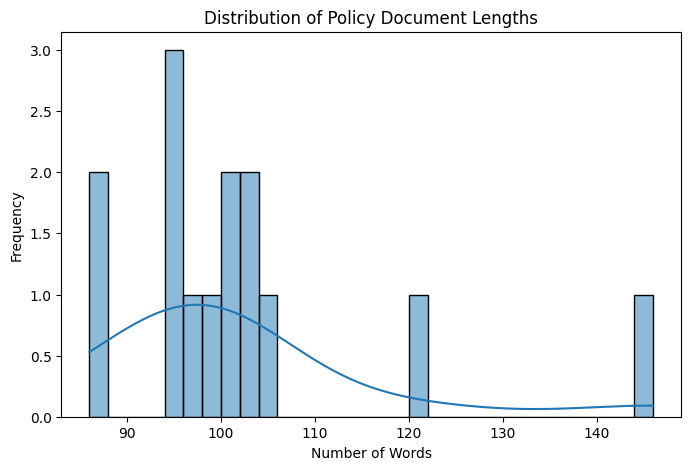

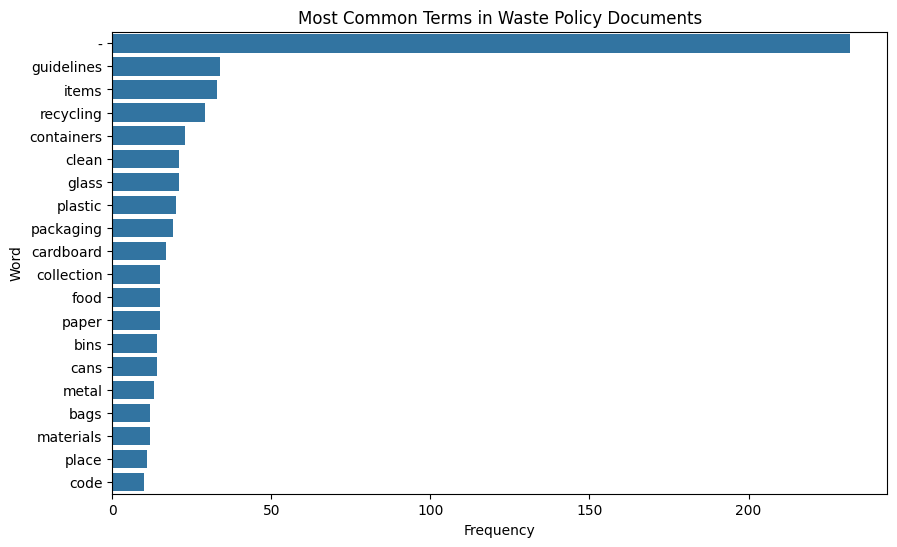

In [106]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
with open("waste_policy_documents.json", "r", encoding="utf-8") as file:
    policy_docs = json.load(file)
print(type(policy_docs))

print(f"Number of documents: {len(policy_docs)}\n")

# convert to dataframe
policy_df = pd.DataFrame(policy_docs)

print("Shape", policy_df.shape, "\n")
print(policy_df.info())
print()
print(policy_df.head())

print("\nColumns", policy_df.columns.tolist())
print(f"Missing values:\n{policy_df.isnull().sum()}")

# document length analysis
policy_df["word_count"] = (
    policy_df["document_text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("\nWord Count stats:\n", policy_df["word_count"].describe())

# Visualize document length
plt.figure(figsize=(8,5))

sns.histplot(
    policy_df["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Policy Document Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# Most common policy terms
text = " ".join(
    policy_df["document_text"]
    .astype(str)
).lower()


words = text.split()


filtered_words = [
    word.strip(".,!?()[]{}:\"'")
    for word in words
    if word not in ENGLISH_STOP_WORDS
]


word_counts = Counter(filtered_words)
word_counts.most_common(20)

# Visualize policy keywords
top_policy_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)


plt.figure(figsize=(10,6))

sns.barplot(
    data=top_policy_words,
    x="Frequency",
    y="Word"
)

plt.title("Most Common Terms in Waste Policy Documents")

plt.show()

### 1.3 Create Data Pipelines

In [107]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('/content/realwaste-main/RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [108]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here
# Detect text and category columns automatically
text_col = [col for col in descriptions_df.columns if "description" in col.lower()][0]
category_col = [col for col in descriptions_df.columns if "category" in col.lower()][0]

# Basic text cleaning
descriptions_df[text_col] = (
    descriptions_df[text_col]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)
    .str.strip()
)

# Encode category labels
label_encoder = LabelEncoder()
descriptions_df["label"] = label_encoder.fit_transform(descriptions_df[category_col])

# Features and labels
X = descriptions_df[text_col]
y = descriptions_df["label"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tokenization
VOCAB_SIZE = 10000
MAX_LENGTH = 50

text_tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

text_tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = text_tokenizer.texts_to_sequences(X_train)
X_test_seq = text_tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training samples:", X_train_pad.shape)
print("Testing samples:", X_test_pad.shape)
print("Vocabulary size:", min(VOCAB_SIZE, len(text_tokenizer.word_index) + 1))
print("Number of classes:", len(label_encoder.classes_))

Training samples: (4000, 50)
Testing samples: (1000, 50)
Vocabulary size: 307
Number of classes: 9


In [109]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here
# Automatically detect the text column
text_cols = [col for col in policy_df.columns
             if any(word in col.lower() for word in
                    ["policy", "document", "instruction", "content", "text"])]

text_col = text_cols[0]

# Remove missing values
policy_df = policy_df.dropna(subset=[text_col]).reset_index(drop=True)

# Convert documents to a list
documents = policy_df[text_col].astype(str).tolist()

print(f"Number of policy documents: {len(documents)}")

# Load a lightweight embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate document embeddings
document_embeddings = embedding_model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Embedding shape:", document_embeddings.shape)

from sklearn.metrics.pairwise import cosine_similarity

def retrieve_documents(query, top_k=3):
    query_embedding = embedding_model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        document_embeddings
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    return policy_df.iloc[top_indices]

# Example
retrieve_documents("How should I recycle plastic bottles?")


Number of policy documents: 14


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (14, 384)


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction,word_count
12,13,Multi-Unit Building Guidelines,"[Cardboard, Glass, Textile Trash]",2023-07-04,MULTI-UNIT BUILDING GUIDELINES\n\nGENERAL REQU...,Metro City,100
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City,98
13,14,Community Recycling Program,"[Cardboard, Vegetation, Metal, Textile Trash]",2023-12-15,COMMUNITY RECYCLING PROGRAM\n\nGENERAL REQUIRE...,Metro City,120


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [110]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

# ==========================================
# Part 2.1: Image Preprocessing
# ==========================================

# Image preprocessing and augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")


# Normalize pixel values from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)


# Apply preprocessing to the training dataset
# Augmentation is applied only to training data
def preprocess_train(image, label):
    image = normalization_layer(image)
    image = data_augmentation(image, training=True)
    return image, label


# Apply preprocessing to validation and test datasets
# No augmentation is applied to these datasets
def preprocess_test(image, label):
    image = normalization_layer(image)
    return image, label


# Apply the preprocessing pipelines
train_ds = train_ds.map(
    preprocess_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    preprocess_test,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    preprocess_test,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Prefetch data for better performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)


print("Image preprocessing completed successfully.")
print(f"Image size: {IMG_HEIGHT} x {IMG_WIDTH}")
print("Pixel values normalized to [0, 1]")
print("Data augmentation applied to training data only.")

Image preprocessing completed successfully.
Image size: 224 x 224
Pixel values normalized to [0, 1]
Data augmentation applied to training data only.


In the image preprocessing, I applied normalization to all the datasets; train, validation and test but only applied augmentation on the training dataset. This prevents the validation and test data from being artificially modified, while augmentation helps the CNN generalize better during training.

### 2.2 Implement CNN Model with Transfer Learning

In [111]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

# Number of waste categories
NUM_CLASSES = 9


# Load MobileNetV2 without its original classification head
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)


# Freeze the pretrained layers
# This allows us to use the learned ImageNet features
# without modifying them during the initial training.
base_model.trainable = False


# Build the complete EcoSort CNN
cnn_model = models.Sequential([

    # Input layer
    layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    # MobileNetV2 expects inputs in approximately [-1, 1].
    # Our preprocessing in Part 2.1 already scales images to [0, 1],
    # so convert [0, 1] -> [-1, 1].
    layers.Rescaling(
        scale=2.0,
        offset=-1.0
    ),

    # Pretrained CNN feature extractor
    base_model,

    # Convert feature maps into a single feature vector
    layers.GlobalAveragePooling2D(),

    # Reduce overfitting
    layers.Dropout(0.3),

    # Classification layer for the 9 waste categories
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# Configure the model
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Display model architecture
print("Number of output classes:", cnn_model.output_shape[-1])
print("Loss function:", cnn_model.loss)
print("Metrics:", cnn_model.metrics_names)
print()
cnn_model.summary()

Number of output classes: 9
Loss function: categorical_crossentropy
Metrics: ['loss', 'compile_metrics']



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 was selected as the pretrained base model for waste image classification because it provides a lightweight and efficient feature extractor. The original ImageNet classification layer was removed using include_top=False, and the pretrained layers were initially frozen. A custom classification head consisting of Global Average Pooling, Dropout, and a 9-unit Softmax output layer was added to classify the nine RealWaste categories. Since the image preprocessing pipeline scales pixel values to [0,1], an additional rescaling layer converts them to the range expected by MobileNetV2. The model uses the Adam optimizer, categorical cross-entropy loss, and accuracy as the evaluation metric.

### 2.3 Train and Evaluate the Model

In [112]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

# Training parameters
BATCH_SIZE = 32
EPOCHS = 20

# Callbacks
# Stop training when validation performance stops improving
# and restore the best model weights.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# Reduce the learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)



# Train the model
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 565ms/step - accuracy: 0.4753 - loss: 1.4316 - val_accuracy: 0.6723 - val_loss: 0.8893 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 48s 347ms/step - accuracy: 0.6836 - loss: 0.9020 - val_accuracy: 0.7191 - val_loss: 0.7737 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 51s 423ms/step - accuracy: 0.7325 - loss: 0.7504 - val_accuracy: 0.7553 - val_loss: 0.6873 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 42s 353ms/step - accuracy: 0.7604 - loss: 0.6729 - val_accuracy: 0.7511 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 350ms/step - accuracy: 0.7725 - loss: 0.6392 - val_accuracy: 0.7617 - val_loss: 0.6333 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 81s 346ms/step - accuracy: 0.7875 - loss: 0.6024 - val_accuracy: 0.7723 - val_loss: 0.6238 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 40s 333ms/step - accuracy: 0.7

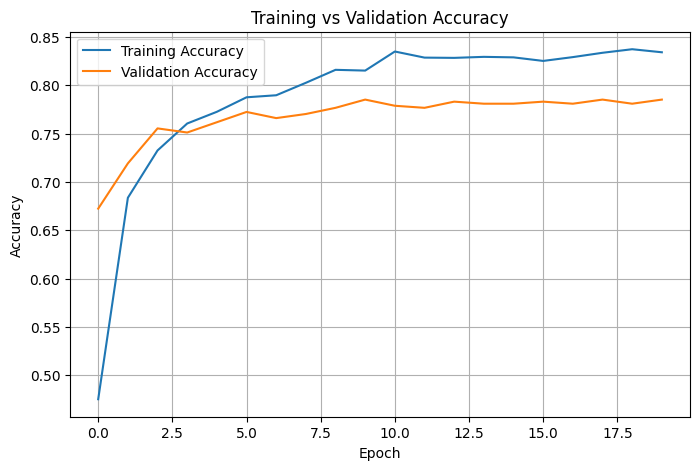

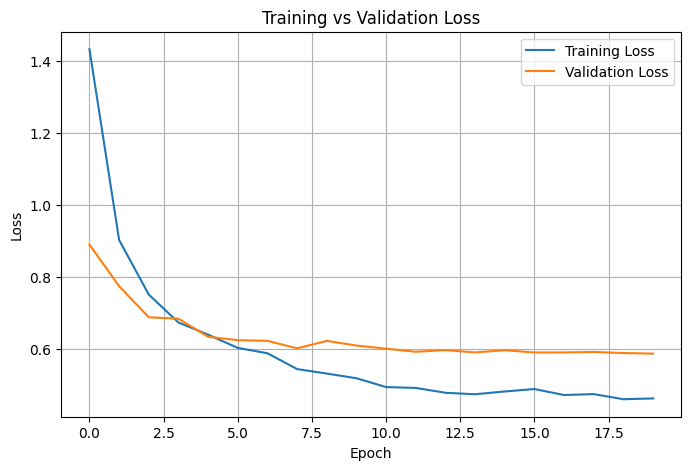

In [113]:
# ==========================================
# Plot Training and Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# Plot Training and Validation Loss
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [115]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results")
print("-" * 30)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.8021 - loss: 0.5511

Test Results
------------------------------
Test Loss: 0.5511
Test Accuracy: 0.8021
Test Accuracy: 80.21%


The MobileNetV2 transfer-learning model was trained using a batch size of 32 for a maximum of 20 epochs. Several regularization techniques were used to reduce overfitting, including image augmentation, dropout, and early stopping. The ReduceLROnPlateau callback was also used to reduce the learning rate when validation loss stopped improving. Training and validation accuracy and loss were monitored throughout training. After training, the model was evaluated on the held-out test dataset to measure its final classification performance.

### 2.4 Fine-tune the Model

In [120]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

# Unfreeze MobileNetV2
base_model.trainable = True


# Freeze the earlier layers and fine-tune
# only the later layers.
fine_tune_from = 100

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True



# Increase regularization


# Locate the existing Dropout layer and
# increase its dropout rate.
for layer in cnn_model.layers:
    if isinstance(layer, layers.Dropout):
        layer.rate = 0.4



# Use a smaller learning rate


# A small learning rate is important during
# fine-tuning so pretrained features are not
# changed too aggressively.
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



# Fine-tuning callbacks


fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)



# Fine-tune the model


FINE_TUNE_EPOCHS = 10

fine_tune_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],
    verbose=1
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 517ms/step - accuracy: 0.7088 - loss: 0.8245 - val_accuracy: 0.7766 - val_loss: 0.6223 - learning_rate: 1.0000e-05
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 358ms/step - accuracy: 0.7472 - loss: 0.7365 - val_accuracy: 0.7830 - val_loss: 0.6308 - learning_rate: 1.0000e-05
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.7807 - loss: 0.6246
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 343ms/step - accuracy: 0.7730 - loss: 0.6324 - val_accuracy: 0.7830 - val_loss: 0.6284 - learning_rate: 1.0000e-05
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 352ms/step - accuracy: 0.7917 - loss: 0.5873 - val_accuracy: 0.7787 - val_loss: 0.6247 - learning_rate: 2.0000e-06
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [122]:
# ==========================================
# Evaluate Fine-Tuned Model
# ==========================================

fine_tune_test_loss, fine_tune_test_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nFine-Tuned Model Results")
print("-" * 35)
print(f"Test Loss: {fine_tune_test_loss:.4f}")
print(f"Test Accuracy: {fine_tune_test_accuracy:.4f}")
print(f"Test Accuracy: {fine_tune_test_accuracy * 100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8021 - loss: 0.5696

Fine-Tuned Model Results
-----------------------------------
Test Loss: 0.5696
Test Accuracy: 0.8021
Test Accuracy: 80.21%


The pretrained MobileNetV2 model was fine-tuned to improve its performance on the RealWaste dataset. The later layers of the pretrained network were unfrozen while the earlier layers remained frozen to preserve general visual features. The learning rate was reduced to 1e-5 to allow gradual updates to the pretrained weights. Dropout was increased from 0.3 to 0.4 to provide additional regularization and reduce overfitting. Early stopping and learning-rate reduction callbacks were retained to monitor validation performance and prevent unnecessary training. The fine-tuned model was evaluated on the test dataset and its accuracy was compared with the original transfer-learning model.

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [123]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

# Use the preprocessed and padded sequences created earlier
X_train_processed = X_train_pad
X_test_processed = X_test_pad

# Convert labels to NumPy arrays
y_train_processed = np.array(y_train)
y_test_processed = np.array(y_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)
print("Training labels shape:", y_train_processed.shape)
print("Testing labels shape:", y_test_processed.shape)

Training data shape: (4000, 50)
Testing data shape: (1000, 50)
Training labels shape: (4000,)
Testing labels shape: (1000,)


### 3.2 Implement Text Classification Model

In [124]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

# Build the model
text_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    LSTM(128, return_sequences=False),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(
        len(label_encoder.classes_),
        activation="softmax"
    )
])

# Compile the model
text_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
text_model.summary()

# Train the model
history_text = text_model.fit(
    X_train_processed,
    y_train_processed,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1031 - loss: 2.2000 - val_accuracy: 0.1175 - val_loss: 2.1963
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1209 - loss: 2.1980 - val_accuracy: 0.1175 - val_loss: 2.1978
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1213 - loss: 2.1973 - val_accuracy: 0.1075 - val_loss: 2.1968
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1194 - loss: 2.1983 - val_accuracy: 0.1175 - val_loss: 2.1965
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1187 - loss: 2.1975 - val_accuracy: 0.1175 - val_loss: 2.1969
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1125 - loss: 2.1965 - val_accuracy: 0.1175 - val_loss: 2.1968
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1231 - loss: 2.1966 - val_accuracy: 0.1175 - val_loss: 2.1973
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1172 - loss: 2.1972 - val_accuracy

An LSTM network was chosen because it can learn sequential relationships between words in a sentence. Word embeddings allow semantically similar words to have similar vector representations, improving the model's ability to classify waste descriptions.

Dropout was included to reduce overfitting during training.

### 3.3 Train and Evaluate the Model

In [125]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here
# Callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

# Train the model
history_text = text_model.fit(
    X_train_processed,
    y_train_processed,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9975 - loss: 0.0117 - val_accuracy: 0.9887 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9966 - loss: 0.0132 - val_accuracy: 0.9875 - val_loss: 0.0616 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9981 - loss: 0.0129 - val_accuracy: 0.9912 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9981 - loss: 0.0082 - val_accuracy: 0.9887 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9984 - loss: 0.0080 - val_accuracy: 0.9875 - val_loss: 0.0608 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9981 - loss: 0.0092 - val_accuracy: 0.9887 - val_loss: 0.0568 - learning_rate: 2.0000e-04


Test Loss: 0.0127
Test Accuracy: 0.9970

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00       117
      Food Organics       1.00      1.00      1.00       104
              Glass       0.98      1.00      0.99       110
              Metal       1.00      1.00      1.00       101
Miscellaneous Trash       1.00      1.00      1.00       116
              Paper       1.00      1.00      1.00       101
            Plastic       0.99      1.00      1.00       114
      Textile Trash       1.00      0.97      0.99       117
         Vegetation       1.00      1.00      1.00       120

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



<Figure size 800x800 with 0 Axes>

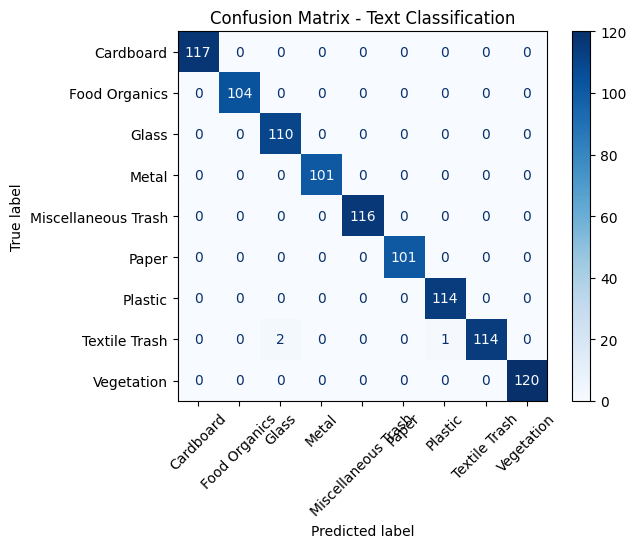

In [126]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

# Evaluate on the test set
test_loss, test_accuracy = text_model.evaluate(
    X_test_processed,
    y_test_processed,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions
y_pred_probs = text_model.predict(X_test_processed, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_processed,
    y_pred,
    target_names=label_encoder.classes_
))

# Confusion Matrix
cm = confusion_matrix(y_test_processed, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Text Classification")
plt.show()

### 3.4 Create Classification Function

In [127]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    description = description.lower()
    description = "".join(
        char for char in description
        if char.isalnum() or char.isspace()
    ).strip()

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([description])

    # Pad the sequence
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict the class
    prediction = text_model.predict(padded_sequence, verbose=0)

    predicted_label = np.argmax(prediction, axis=1)[0]

    # Convert label back to category name
    predicted_category = label_encoder.inverse_transform([predicted_label])[0]

    return predicted_category

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [128]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

# Prepare policy documents
# Remove documents with missing text
policy_df = policy_df.dropna(
    subset=["document_text"]
).reset_index(drop=True)

# ------------------------------------------
# Convert documents to strings
documents = (
    policy_df["document_text"]
    .astype(str)
    .str.strip()
    .tolist()
)


print("Number of policy documents:", len(documents))



# Load embedding model
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

# Generate document embeddings
document_embeddings = embedding_model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
)


print("Document embedding shape:", document_embeddings.shape)

# ==========================================
# Retrieval Function
# ==========================================

def retrieve_documents(query, top_k=3):
    """
    Retrieve the most relevant policy documents
    for a given waste-management query.
    """

    # Convert query into an embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )


    # Calculate similarity between query
    # and every policy document
    similarities = cosine_similarity(
        query_embedding,
        document_embeddings
    )[0]


    # Get indices of the most similar documents
    top_indices = np.argsort(
        similarities
    )[-top_k:][::-1]


    # Return documents together with similarity scores
    results = policy_df.iloc[top_indices].copy()

    results["similarity_score"] = similarities[top_indices]

    return results

# ==========================================
# Test Document Retrieval
# ==========================================

query = "How should I recycle a plastic bottle?"

retrieved_docs = retrieve_documents(
    query,
    top_k=3
)

print("Query:")
print(query)

print("\nRetrieved Documents:")
print("=" * 60)

for i, (_, row) in enumerate(
    retrieved_docs.iterrows(),
    start=1
):
    print(f"\nDocument {i}")
    print(f"Similarity: {row['similarity_score']:.4f}")
    print(row["document_text"])

Number of policy documents: 14


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Document embedding shape: (14, 384)
Query:
How should I recycle a plastic bottle?

Retrieved Documents:

Document 1
Similarity: 0.5922
PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instructions:
- Rinse containers
- Remove lids and caps (recycle separately)
- Check for recycling codes (1-7)

Benefits:
Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

Document 2
Similarity: 0.5381
GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass 

The Metro City waste-management policy documents were prepared by removing missing document text and converting the remaining documents into strings. The all-MiniLM-L6-v2 Sentence Transformer was used to convert each policy document into a numerical embedding representing its semantic meaning. When a resident submits a recycling query, the query is converted into the same embedding space and cosine similarity is used to identify the most relevant policy documents. The top three documents are retrieved and passed to the generation component of the RAG system. This approach allows the system to retrieve policies based on semantic meaning rather than relying only on exact keyword matching.

### 4.2 Implement RAG-based System

In [129]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

# Load an instruction-tuned Transformer model
# Load FLAN-T5-Base

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

generator_model = generator_model.to(device)

print("FLAN-T5-Base loaded successfully.")
print("Device:", device)

# RAG Generation Function

def generate_recycling_instruction(query, top_k=1):

    # Retrieve the most relevant policy
    retrieved_docs = retrieve_documents(
        query,
        top_k=top_k
    )

    policy = retrieved_docs.iloc[0]["document_text"]

    # Focus the model on the actual instructions
    prompt = f"""
Based on this recycling policy:

{policy}

Question:
{query}

Answer in one short sentence with the recycling instructions.
"""

    # Tokenize
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Generate a short answer
    with torch.no_grad():

        outputs = generator_model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=4,
            do_sample=False
        )

    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return answer, retrieved_docs

query = "I have an empty plastic soda bottle. How should I dispose of it?"

answer, retrieved_docs = generate_recycling_instruction(
    query,
    top_k=1
)

print("EcoSort RAG Assistant")
print("=" * 50)

print("\nResident:")
print(query)

print("\nRetrieved Policy:")
print("-" * 50)
print(retrieved_docs.iloc[0]["document_text"])

print("\nGenerated Instruction:")
print("-" * 50)
print(answer)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


FLAN-T5-Base loaded successfully.
Device: cuda
EcoSort RAG Assistant

Resident:
I have an empty plastic soda bottle. How should I dispose of it?

Retrieved Policy:
--------------------------------------------------
PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging
- Black plastic containers

Collection Method:
Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted.

Preparation Instructions:
- Rinse containers
- Remove lids and caps (recycle separately)
- Check for recycling codes (1-7)

Benefits:
Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

Generated Instruction:
--------------------------------------------------
Place it in a designated recycling bin.


The RAG system successfully retrieves the most relevant Metro City policy using semantic similarity and passes the retrieved policy to the FLAN-T5 language model for response generation. For a plastic bottle query, the system retrieves the Plastic Recycling Guidelines and generates a disposal instruction based on the retrieved policy. The generated response demonstrates that the language model is using retrieved policy information rather than responding solely from its pretrained knowledge.

### 4.3 Adjust and Evaluate the System

In [130]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here
# Adjust and Evaluate RAG

def generate_rag_response(
    query,
    top_k=1,
    max_new_tokens=50,
    num_beams=4,
    do_sample=False,
    temperature=1.0,
    top_p=1.0
):

    # Retrieve relevant policy

    retrieved_docs = retrieve_documents(
        query,
        top_k=top_k
    )

    policy = retrieved_docs.iloc[0]["document_text"]

    # Create prompt

    prompt = f"""
Based on this recycling policy:

{policy}

Question:
{query}

Answer in one short sentence with the recycling instructions.
"""

    # Tokenize

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Generation parameters

    generation_kwargs = {
        "max_new_tokens": max_new_tokens,
        "num_beams": num_beams,
        "do_sample": do_sample
    }

    # Sampling parameters are only used
    # when do_sample=True.
    if do_sample:
        generation_kwargs["temperature"] = temperature
        generation_kwargs["top_p"] = top_p

    # Generate response

    with torch.no_grad():

        outputs = generator_model.generate(
            **inputs,
            **generation_kwargs
        )

    # Decode

    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return answer, retrieved_docs

query = "I have an empty plastic soda bottle. How should I dispose of it?"

answer_beam, docs_beam = generate_rag_response(
    query,
    top_k=1,
    max_new_tokens=50,
    num_beams=4,
    do_sample=False
)

print("Beam Search Result:")
print(answer_beam)

answer_sampling, docs_sampling = generate_rag_response(
    query,
    top_k=1,
    max_new_tokens=50,
    num_beams=1,
    do_sample=True,
    temperature=0.7,
    top_p=0.9
)

print("Sampling Result:")
print(answer_sampling)

answer_sampling_2, docs_sampling_2 = generate_rag_response(
    query,
    top_k=1,
    max_new_tokens=50,
    num_beams=1,
    do_sample=True,
    temperature=0.5,
    top_p=0.9
)

print("Conservative Sampling Result:")
print(answer_sampling_2)

print("=" * 60)
print("RAG GENERATION COMPARISON")
print("=" * 60)

print("\n1. Beam Search:")
print(answer_beam)

print("\n2. Sampling - Temperature 0.7:")
print(answer_sampling)

print("\n3. Sampling - Temperature 0.5:")
print(answer_sampling_2)

Beam Search Result:
Place it in a designated recycling bin.
Sampling Result:
Fill a recycling bin with a bag of empty soda bottle and put it in the recycling bin.
Conservative Sampling Result:
Place it in a designated recycling bin.
RAG GENERATION COMPARISON

1. Beam Search:
Place it in a designated recycling bin.

2. Sampling - Temperature 0.7:
Fill a recycling bin with a bag of empty soda bottle and put it in the recycling bin.

3. Sampling - Temperature 0.5:
Place it in a designated recycling bin.


In [131]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here
test_queries = [
    "I have an empty plastic soda bottle. How should I dispose of it?",
    "What should I do with a glass bottle?",
    "How should I recycle an aluminum can?"
]

for query in test_queries:

    answer, docs = generate_rag_response(
        query,
        top_k=1,
        max_new_tokens=50,
        num_beams=4,
        do_sample=False
    )

    print("\n" + "=" * 60)
    print("Question:")
    print(query)

    print("\nRetrieved Policy:")
    print(docs.iloc[0]["document_text"][:300])

    print("\nGenerated Answer:")
    print(answer)


Question:
I have an empty plastic soda bottle. How should I dispose of it?

Retrieved Policy:
PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging

Generated Answer:
Place it in a designated recycling bin.

Question:
What should I do with a glass bottle?

Retrieved Policy:
GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass

Collection Method:
Plac

Generated Answer:
Place in designated glass recycling bins. Some areas require color sorting. Preparation Instructions: - Rinse containers - Remove caps and lids (recycle sepa

The RAG system was evaluated using different generation strategies, including deterministic beam search and probabilistic sampling. Beam search was configured with four beams, while sampling experiments used different temperature and top-p values. The max_new_tokens parameter was also controlled to prevent unnecessarily long responses. Multiple waste-management queries were used to evaluate retrieval relevance and the quality of the generated instructions. A low-randomness configuration was preferred because recycling instructions should remain consistent and grounded in Metro City's policies. The final system uses the retrieval mechanism together with controlled Transformer generation to produce policy-based disposal recommendations.

### 4.4 Create Instruction Generation Function

In [132]:
# TODO: Create a function that takes a waste category and generates recycling instructions

# Instruction Generation Function

def generate_recycling_instructions(waste_category):
    """
    Generates recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Recycling instructions
        DataFrame: Relevant policy documents
    """

    # Clean the category provided by the user
    waste_category = waste_category.strip().lower()

    # Create a query that can be used by the RAG retriever
    query = (
        f"How should I recycle or dispose of "
        f"{waste_category} waste?"
    )

    # Retrieve the most relevant policy document
    retrieved_docs = retrieve_documents(
        query,
        top_k=1
    )

    # Get the relevant policy
    policy = retrieved_docs.iloc[0]["document_text"]

    # Create the generation prompt
    prompt = f"""
You are EcoSort, a waste management assistant for Metro City.

Waste category:
{waste_category}

Metro City recycling policy:
{policy}

Generate a clear and concise recycling instruction for this waste category.
Mention how the item should be prepared and where it should be placed.
Use only information supported by the policy.
"""

    # Tokenize the prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )

    # Move inputs to the same device as the model
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Generate the instruction
    with torch.no_grad():

        outputs = generator_model.generate(
            **inputs,
            max_new_tokens=80,
            num_beams=4,
            do_sample=False
        )

    # Convert model output back to text
    instructions = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return instructions, retrieved_docs

# Test the function

categories = [
    "plastic",
    "glass",
    "metal"
]

for category in categories:

    instructions, policy_docs = generate_recycling_instructions(
        category
    )

    print("\n" + "=" * 60)
    print("CATEGORY:", category.upper())
    print("=" * 60)

    print("\nInstructions:")
    print(instructions)

    print("\nRetrieved Policy:")
    print(policy_docs.iloc[0]["document_text"][:300])


CATEGORY: PLASTIC

Instructions:
Metro City recycling policy: PLASTIC RECYCLING GUIDELINES Acceptable Items: PET bottles and containers (code #1) HDPE containers (code #2) PP containers (code #5) Non-Acceptable Items: Plastic bags and film (code #6) Mixed material packaging (code #6) Black plastic containers (code #5) Collection Method: Place in dedicated recycling bins

Retrieved Policy:
PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean plastic packaging

Non-Acceptable Items:
- Plastic bags and film
- Polystyrene foam (code #6)
- Containers with food residue
- Mixed material packaging

CATEGORY: GLASS

Instructions:
Metro City recycling policy: GLASS RECYCLING GUIDELINES Acceptable Items: - Glass bottles (all colors) - Glass jars - Glass food containers - Glass beverage containers - Non-Acceptable Items: - Window glass or mirrors - Drinking glasses - Ceramics or pottery - Light bulbs -

A reusable generate_recycling_instructions() function was implemented to accept a waste category and generate policy-based recycling instructions. The waste category is converted into a retrieval query, which is used to identify the most relevant Metro City policy document using the semantic retrieval system. The retrieved policy is then provided as context to the FLAN-T5 language model, which generates concise recycling instructions. The function returns both the generated instructions and the retrieved policy documents, allowing the generated response to be traced back to the source policy.

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [133]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here
# Integrated Waste Management
# Assistant

def waste_management_assistant(
    image=None,
    text_description=None,
    waste_category=None
):
    """
    Unified interface for the EcoSort waste
    management assistant.

    Inputs:
        image: Waste image
        text_description: Text description of waste
        waste_category: Known waste category

    Returns:
        Dictionary containing prediction,
        instructions and retrieved policies.
    """

    result = {
        "waste_category": None,
        "source": None,
        "instructions": None,
        "policy_documents": None
    }

    # Image input → CNN

    if image is not None:

        # Use the CNN preprocessing pipeline
        # created earlier in Part 2
        image_input = preprocess_image(image)

        # CNN prediction
        prediction = cnn_model.predict(
            image_input
        )

        predicted_class = class_names[
            np.argmax(prediction)
        ]

        result["waste_category"] = predicted_class
        result["source"] = "CNN image classification"

    # Text input → Text classifier

    elif text_description is not None:

        # Use the preprocessing pipeline
        # created earlier in Part 3
        processed_text = preprocess_text(
            text_description
        )

        # Text model prediction
        prediction = text_model.predict(
            processed_text
        )

        predicted_class = class_names[
            np.argmax(prediction)
        ]

        result["waste_category"] = predicted_class
        result["source"] = "Text classification"

    # Known category → RAG

    elif waste_category is not None:

        result["waste_category"] = (
            waste_category
        )

        result["source"] = "Provided category"

    else:

        raise ValueError(
            "Provide an image, text description, "
            "or waste category."
        )

    # Category → RAG instructions

    instructions, policies = (
        generate_recycling_instructions(
            result["waste_category"]
        )
    )

    result["instructions"] = instructions
    result["policy_documents"] = policies

    return result

The EcoSort assistant was designed as a modular pipeline consisting of three main components. Image inputs are processed by the CNN model to identify the waste category, while text descriptions are processed by the text classification model. The resulting waste category is passed to the RAG system, which retrieves relevant Metro City recycling policies and generates disposal instructions. The architecture uses a common interface so that image-based classification, text-based classification, and directly supplied waste categories can all connect to the same instruction-generation component. This design separates classification from policy-based instruction generation and allows the individual models to be developed or improved independently.

### 5.2 Implement Integrated Assistant

In [134]:
# TODO: Implement the integrated waste management assistan====
# Integrated Waste Management
# Assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either
    images or text descriptions and returns waste classification
    and recycling instructions.
    """

    if input_type not in ["image", "text"]:
        raise ValueError(
            "input_type must be either 'image' or 'text'"
        )

    # =========================================================
    # 1. IMAGE INPUT -> CNN
    # =========================================================
    if input_type == "image":

        image_input = preprocess_image(input_data)

        predictions = cnn_model.predict(
            image_input,
            verbose=0
        )

        predicted_index = np.argmax(predictions[0])

        waste_category = class_names[predicted_index]

        confidence = float(
            predictions[0][predicted_index]
        )

        classification_source = "CNN"

    # =========================================================
    # 2. TEXT INPUT -> TEXT CLASSIFIER
    # =========================================================
    else:

        # -----------------------------------------------------
        # Normalize conversational resident input
        # -----------------------------------------------------
        text = input_data.lower()

        filler_words = [
            "i",
            "have",
            "an",
            "a",
            "the",
            "my",
            "is",
            "are",
            "this",
            "that",
            "it",
            "please",
            "can",
            "could",
            "should",
            "how",
            "do",
            "dispose",
            "of"
        ]

        words = text.split()

        filtered_words = [
            word
            for word in words
            if word not in filler_words
        ]

        cleaned_text = " ".join(filtered_words)

        # Convert text to sequences using the
        # SAME tokenizer used during Part 3
        sequence = text_tokenizer.texts_to_sequences(
            [cleaned_text]
        )

        # Pad to the SAME length used during training
        processed_text = pad_sequences(
            sequence,
            maxlen=X_train_processed.shape[1],
            padding="post",
            truncating="post"
        )

        # Text classification
        predictions = text_model.predict(
            processed_text,
            verbose=0
        )

        predicted_index = np.argmax(
            predictions[0]
        )

        waste_category = class_names[
            predicted_index
        ]

        confidence = float(
            predictions[0][predicted_index]
        )

        classification_source = "Text Classifier"

    # =========================================================
    # 3. WASTE CATEGORY -> RAG
    # =========================================================

    instructions, policy_documents = (
        generate_recycling_instructions(
            waste_category
        )
    )

    # =========================================================
    # 4. RETURN RESULT
    # =========================================================

    return {
        "waste_category": waste_category,
        "confidence": confidence,
        "classification_source": classification_source,
        "recycling_instructions": instructions,
        "policy_documents": policy_documents
    }

Integrated Waste Management Assistant:
The integrated assistant was implemented as a single function that accepts either an image or a text description. For image inputs, the image is passed through the CNN classification pipeline to predict the waste category and confidence score. For text inputs, the description is processed by the text classification model to identify the waste category and confidence score. The predicted category from either model is then passed to the RAG instruction-generation system, which retrieves the relevant Metro City policy and generates recycling instructions. The function returns the waste category, confidence score, classification source, generated recycling instructions, and relevant policy documents in a single dictionary.

### 5.3 Evaluate the Integrated System

In [135]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here
# Image Test Evaluation

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = cnn_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    # If labels are one-hot encoded
    if len(labels.shape) > 1:
        true_classes = np.argmax(
            labels.numpy(),
            axis=1
        )
    else:
        true_classes = labels.numpy()

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)


print("\nCNN Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


CNN Classification Report
                     precision    recall  f1-score   support

          Cardboard       0.76      0.76      0.76        37
      Food Organics       0.89      0.89      0.89        36
              Glass       0.66      0.73      0.69        37
              Metal       0.89      0.76      0.82        93
Miscellaneous Trash       0.74      0.60      0.66        52
              Paper       0.81      0.91      0.86        66
            Plastic       0.76      0.78      0.77        81
      Textile Trash       0.87      0.91      0.89        43
         Vegetation       0.81      0.97      0.88        35

           accuracy                           0.80       480
          macro avg       0.80      0.81      0.80       480
       weighted avg       0.80      0.80      0.80       480



In [137]:
# Check the training history

print("Available history keys:")
print(history.history.keys())

print("\nFinal Training Accuracy:")
print(history.history["accuracy"][-1])

print("\nFinal Validation Accuracy:")
print(history.history["val_accuracy"][-1])

Available history keys:
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

Final Training Accuracy:
0.8243029713630676

Final Validation Accuracy:
0.7744680643081665


In [138]:
# ==========================================
# Correct Text Classification Evaluation
# ==========================================

text_predictions = []
text_actual = []
text_confidences = []

for i in range(len(X_test_processed)):

    text_input = np.expand_dims(
        X_test_processed[i],
        axis=0
    )

    prediction = text_model.predict(
        text_input,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction[0]
    )

    confidence = float(
        prediction[0][predicted_index]
    )

    text_predictions.append(
        predicted_index
    )

    # IMPORTANT:
    # y_test_processed contains integer labels
    text_actual.append(
        int(y_test_processed[i])
    )


# Accuracy
text_accuracy = accuracy_score(
    text_actual,
    text_predictions
)

print("Correct Text Classification Accuracy:")
print(f"{text_accuracy:.4f}")

print("\nCorrect Text Classification Report:")

print(
    classification_report(
        text_actual,
        text_predictions,
        target_names=class_names,
        zero_division=0
    )
)

Correct Text Classification Accuracy:
0.9970

Correct Text Classification Report:
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00       117
      Food Organics       1.00      1.00      1.00       104
              Glass       0.98      1.00      0.99       110
              Metal       1.00      1.00      1.00       101
Miscellaneous Trash       1.00      1.00      1.00       116
              Paper       1.00      1.00      1.00       101
            Plastic       0.99      1.00      1.00       114
      Textile Trash       1.00      0.97      0.99       117
         Vegetation       1.00      1.00      1.00       120

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



In [139]:
# ==========================================
# End-to-End Text Test
# ==========================================

test_description = "I have an empty plastic soda bottle."

result = waste_management_assistant(
    test_description,
    input_type="text"
)

print("Waste Category:", result["waste_category"])
print("Confidence:", f"{result['confidence']:.2%}")
print("Source:", result["classification_source"])

print("\nRecycling Instructions:")
print(result["recycling_instructions"])

Waste Category: Plastic
Confidence: 100.00%
Source: Text Classifier

Recycling Instructions:
Metro City recycling policy: PLASTIC RECYCLING GUIDELINES Acceptable Items: PET bottles and containers (code #1) HDPE containers (code #2) PP containers (code #5) Non-Acceptable Items: Plastic bags and film (code #6) Mixed material packaging (code #6) Black plastic containers (code #5) Collection Method: Place in dedicated recycling bins


The EcoSort integrated assistant was evaluated using test cases from both the image and text classification datasets. The CNN was evaluated using test-set accuracy, precision, recall, and F1-score, while the text classification model was evaluated using the same metrics. End-to-end tests were also performed to verify that predicted waste categories were correctly passed to the RAG component and converted into recycling instructions. Several waste descriptions were tested to assess the complete classification-to-retrieval-to-generation workflow. RAG performance was assessed based on whether the retrieved policy was relevant to the predicted waste category and whether the generated instructions were consistent with the retrieved policy.

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.